Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-01-30 (+15 weeks)
Dataloader temporal windowing: extending data collection from 2006-01-30 to 2005-10-17 (+15 weeks)
Dataloader temporal windowing: extending data collection from 2006-01-30 to 2005-10-17 (+15 weeks)

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 1])
➡️  Ground truth shape: torch.Size([38, 1])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=(38, 3, 12), y=(38, 1), edge_index=(2, 210), edge_weight=(210,))
Epoch 1 train loss: 0.8091, val loss: 1.8577 ✓ (new best)
Epoch 2 train loss: 0.7367, val loss: 1.4977 ✓ (new best)
Epoch 3 train loss: 0.6725, val loss: 1.1737 ✓ (new best)
Epoch 4 train loss: 0.6097, val loss: 0.8954 ✓ (new best)
Epoch 5 train loss: 0.5661, val loss: 0.7171 ✓ (new best)
Epoch 6 train loss: 0.5387, val loss: 0.6205 ✓ (new best)
Epoch 7 train loss: 0.5181, val loss: 0.5569 ✓ (new best)
Epoch 8 train loss: 0.4998, val loss: 0.5

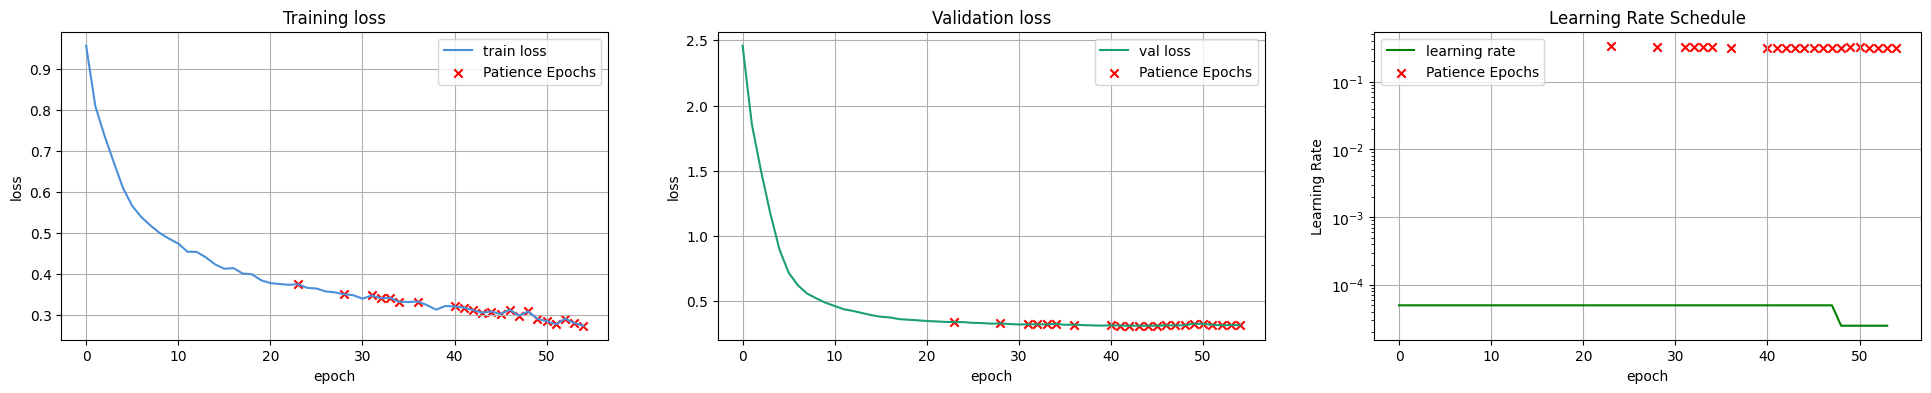

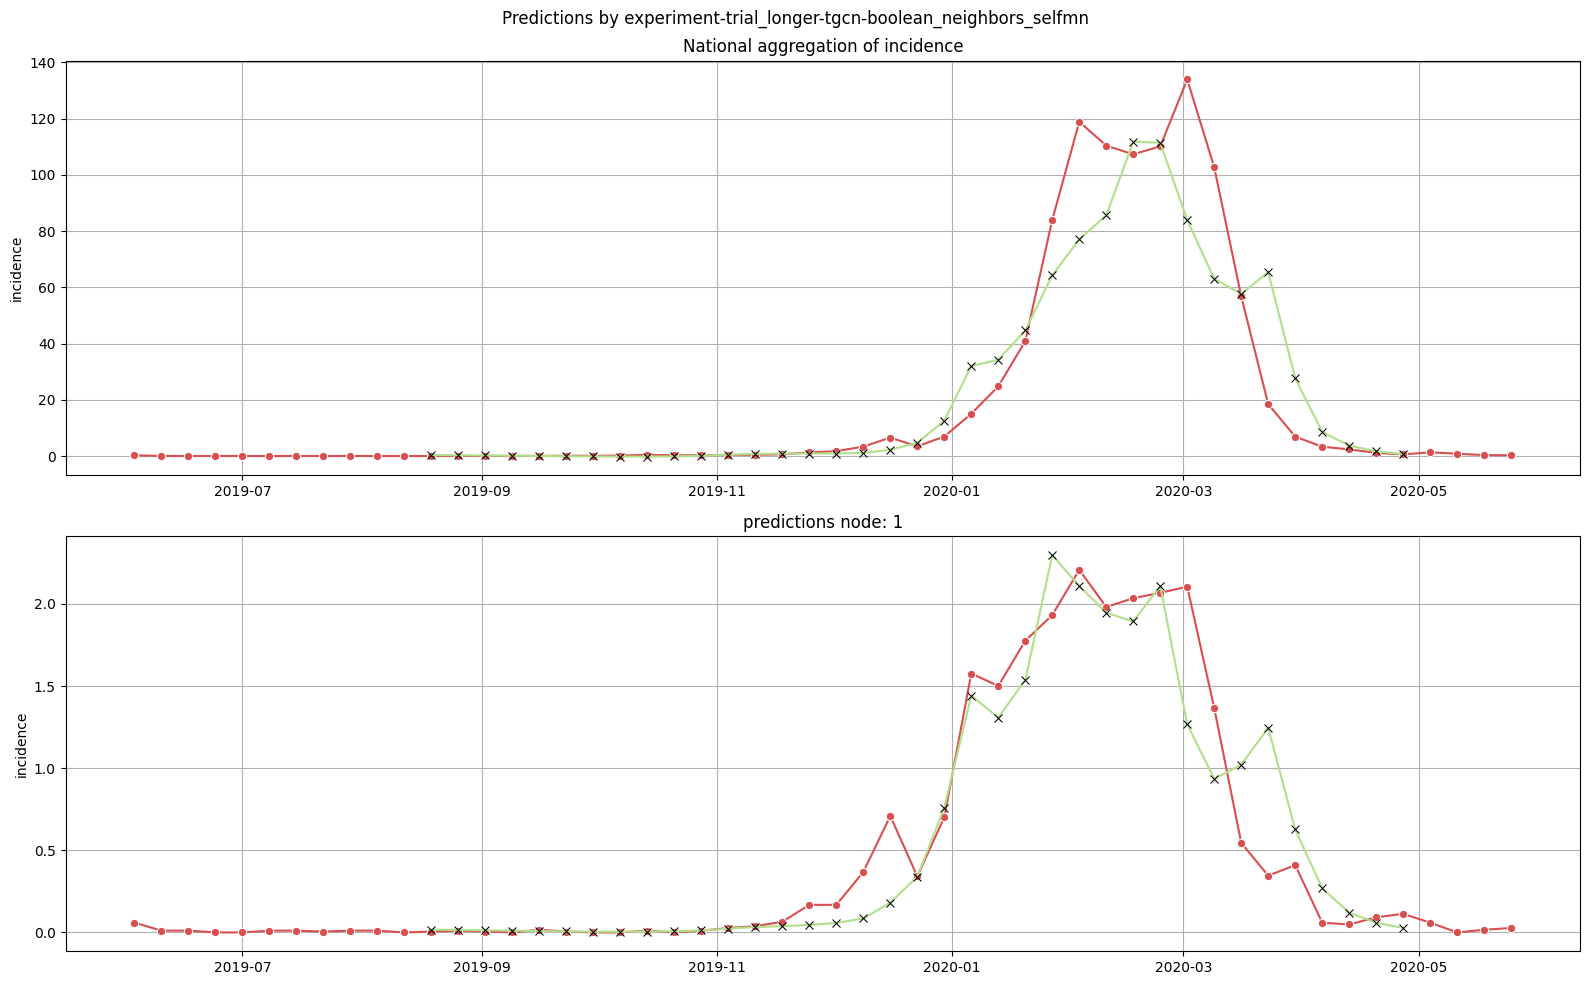

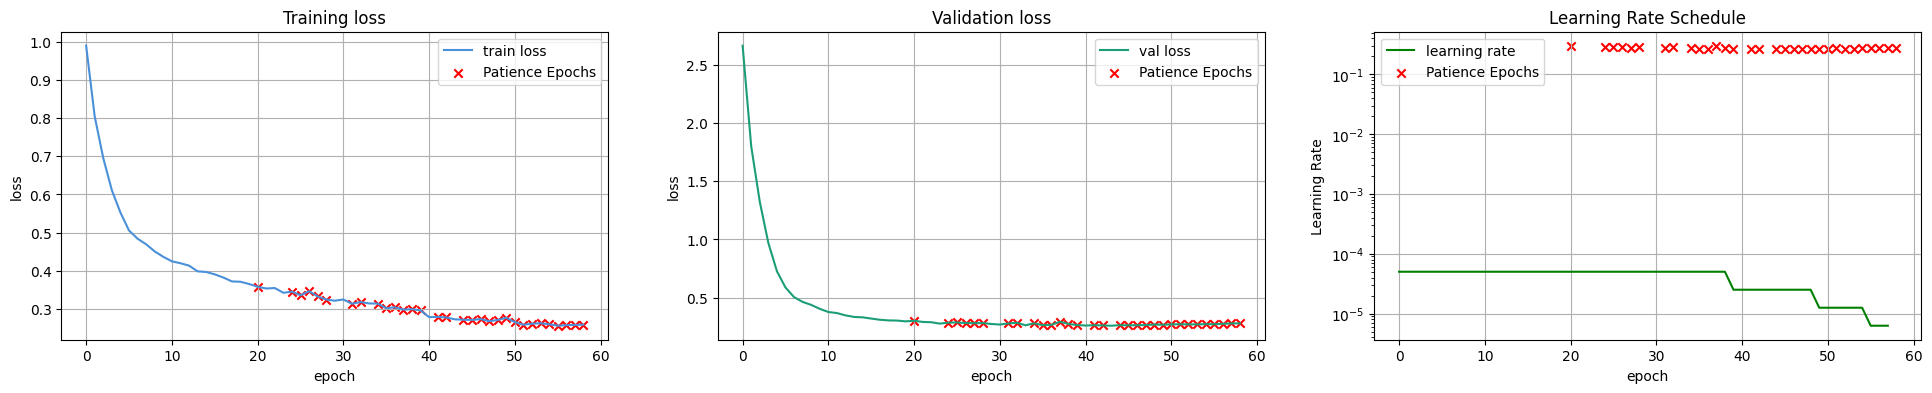

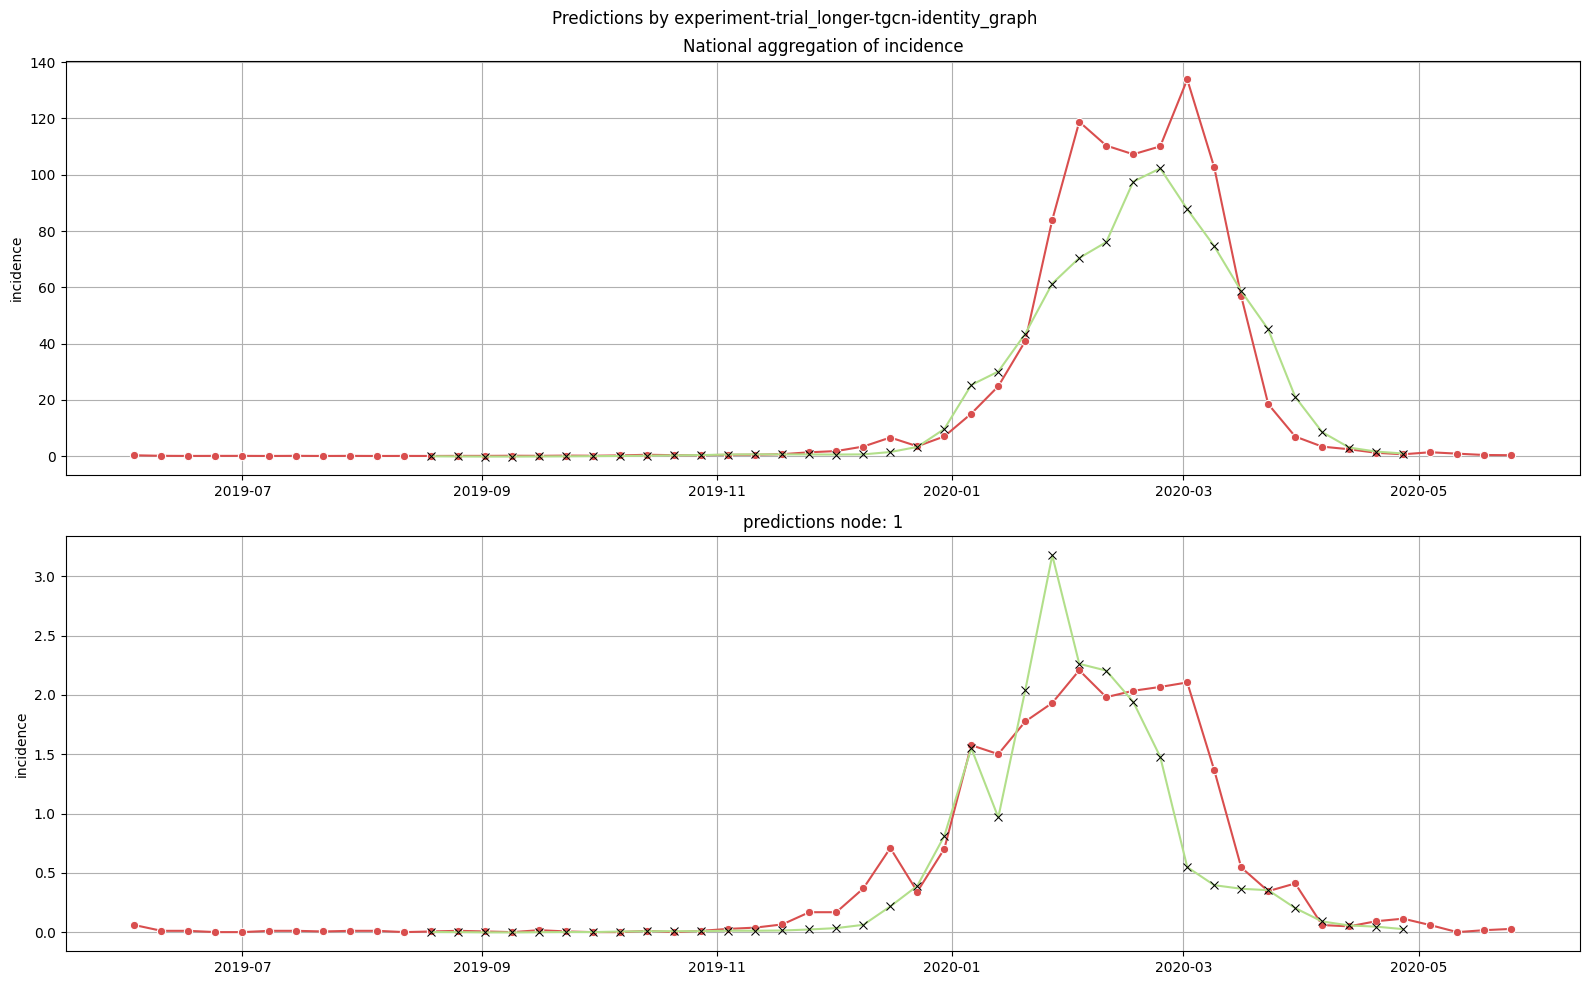

In [2]:
from src.configmanager.experimentconfigmanager import ExperimentConfigManager

n_epochs = 250
lr       = 0.00005
min_delta = 0.001
loss = 'mse'



global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    'min_delta'         : min_delta,
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 5},    
    'loss'              : loss
    }

experiment1 = ExperimentConfigManager()
experiment1.define(experiment_name = 'trial_longer', 
                   disease_name    = 'influenza',
                   model           = 'tgcn', 
                   min_date='2006-05-15',
                   max_date= '2020-06-01',
                   global_hparams = global_hparams, 
                   split_trainval= '2018-06-01',
                   split_valtest='2019-06-01',
                   horizon_size = 1,
                   horizon_leadtime = 3,
                   sequence_length=12,
                   lags =  1,
                    train_hparams=    {"verbose": 2},
                   graphs=['boolean_neighbors_selfmn','identity_graph'])
experiment1.execute('trial_longer')


/local/job_21758305/ipykernel_2224803/3992346783.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  node_specific_corr = predictions_df.groupby(self.id_col).apply(self._return_spearman_corr).rename("corr").reset_index()
/local/job_21758305/ipykernel_2224803/3992346783.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  node_specific_mse = predictions_df.groupby(self.id_col).apply(self._return_mse).rename

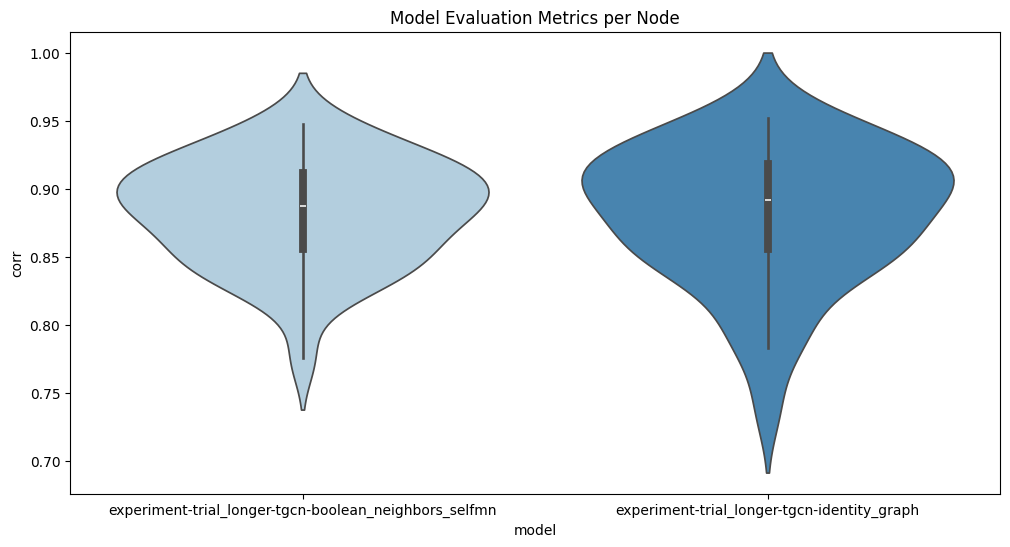

In [19]:


evaluation = Evaluator(list(experiment1.models_dict.values()))
evaluation.add_evaluation(horizon = 0)
# evaluation.plot_metric('corr')
evaluation.plot_metric(metric = 'corr')
# evaluation.plot_metric('mse')

In [20]:
models = list(experiment1.models_dict.values())

Test loss: 0.2133


(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 24'}, ylabel='incidence'>],
       dtype=object))

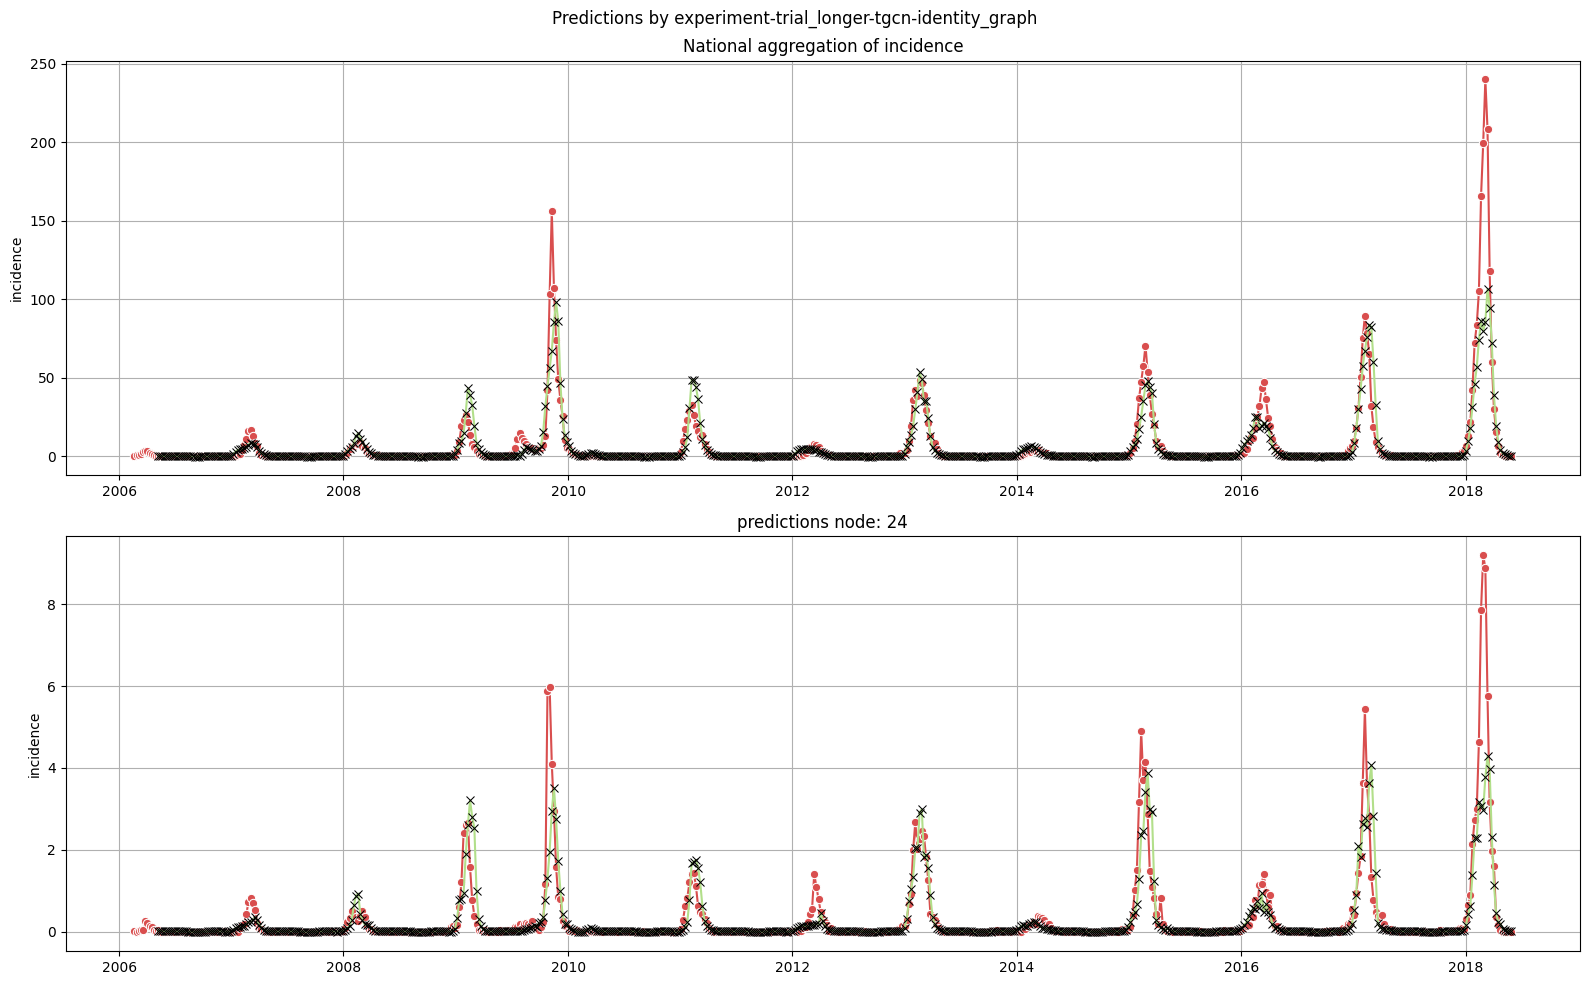

In [29]:
models[1].forecast('train')
models[1].show_forecasts('train',24)